In [1]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.util import random_noise

# ==========================================
# 1. CONFIGURATION & SETUP
# ==========================================
TRAIN_IMG_DIR = '/content/drive/MyDrive/infosys_oil_detection/images/train/'
TRAIN_MASK_DIR = '/content/drive/MyDrive/infosys_oil_detection/masks/masks/train'
VAL_IMG_DIR = '/content/drive/MyDrive/infosys_oil_detection/images/val/'
VAL_MASK_DIR = '/content/drive/MyDrive/infosys_oil_detection/masks/masks/val'


In [2]:
# Target settings for preprocessing
TARGET_SIZE = (256, 256)  # (Width, Height)

def load_file_pairs(img_dir, mask_dir):
    """
    Matches images to masks by filename.
    Assumes filenames are identical or predictable.
    """
    img_paths = sorted(glob.glob(os.path.join(img_dir, '*.png')))
    mask_paths = sorted(glob.glob(os.path.join(mask_dir, '*.png')))

    # Basic check to ensure lists are not empty
    if not img_paths:
        print(f"⚠️ Warning: No images found in {img_dir}")
    if not mask_paths:
        print(f"⚠️ Warning: No masks found in {mask_dir}")

    return img_paths, mask_paths

# Load data lists
train_imgs, train_masks = load_file_pairs(TRAIN_IMG_DIR, TRAIN_MASK_DIR)

In [3]:
# ==========================================
# 2. EDA TASKS
# ==========================================

def visualize_sample(img_path, mask_path, title_prefix="Raw"):
    """
    Loads and displays an image, its mask, and an overlay.
    """
    # Load Image (Use UNCHANGED to support 16-bit SAR if needed)
    image = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)

    # Load Mask (Load as grayscale)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if image is None or mask is None:
        return None, None

    # Handle multi-channel images (convert BGR to RGB if needed)
    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Check Dimensions
    print(f"--- {title_prefix} Analysis ---")
    print(f"Image Shape: {image.shape} | Data Type: {image.dtype}")
    print(f"Mask Shape:  {mask.shape} | Data Type: {mask.dtype}")

    if image.shape[:2] != mask.shape[:2]:
        print("⚠️ ALERT: Image and Mask dimensions do not match!")

    # Plotting
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    # 1. Original Image
    if len(image.shape) == 2: # Grayscale/SAR
        ax[0].imshow(image, cmap='gray')
    else:
        ax[0].imshow(image)
    ax[0].set_title(f"{title_prefix} Image")
    ax[0].axis('off')

    # 2. Mask
    ax[1].imshow(mask, cmap='jet', alpha=0.7) # Jet cmap helps distinguish classes
    ax[1].set_title("Ground Truth Mask")
    ax[1].axis('off')

    # 3. Overlay (Image + Mask)
    # Normalize image for display if it's 16-bit
    img_disp = image.copy()
    if img_disp.dtype != np.uint8:
        img_disp = cv2.normalize(img_disp, None, 0, 255, cv2.NORM_MINMAX).astype('uint8')

    ax[2].imshow(img_disp, cmap='gray')
    ax[2].imshow(mask, cmap='jet', alpha=0.3) # Overlay with transparency
    ax[2].set_title("Overlay Check")
    ax[2].axis('off')

    plt.tight_layout()
    plt.show()
    return image, mask

In [4]:
def analyze_sar_noise(image):
    """
    Analyzes pixel intensity distribution to observe SAR speckle patterns.
    """
    plt.figure(figsize=(12, 4))

    # Histogram of pixel intensities
    plt.subplot(1, 2, 1)
    sns.histplot(image.ravel(), bins=50, kde=True, color='purple')
    plt.title("Pixel Intensity Distribution (Global)")
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")

    # Zoom into a patch to see Speckle Noise visually
    h, w = image.shape[:2]
    # Center crop 50x50
    patch = image[h//2-25 : h//2+25, w//2-25 : w//2+25]

    plt.subplot(1, 2, 2)
    if len(patch.shape) == 2:
        plt.imshow(patch, cmap='gray')
    else:
        plt.imshow(patch)
    plt.title("Zoomed Noise/Texture Pattern (50x50)")
    plt.axis('off')

    plt.show()



## 1. Initial Inspection
--- Raw Analysis ---
Image Shape: (256, 256, 3) | Data Type: uint8
Mask Shape:  (256, 256) | Data Type: uint8


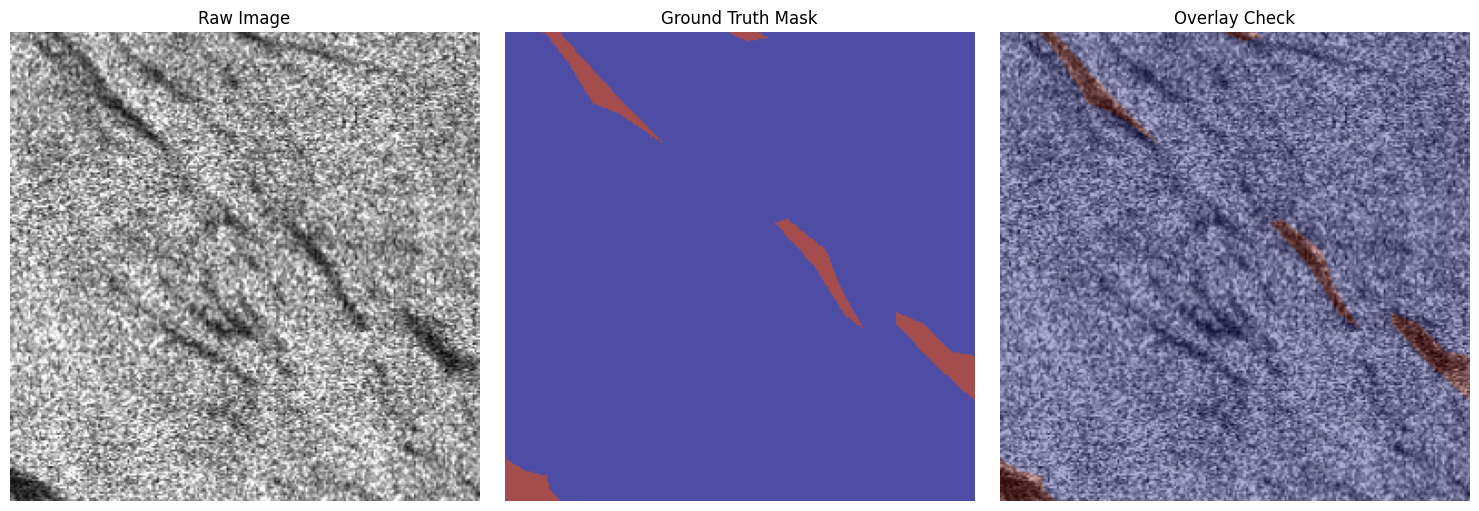


## 2. SAR Noise & Intensity Analysis


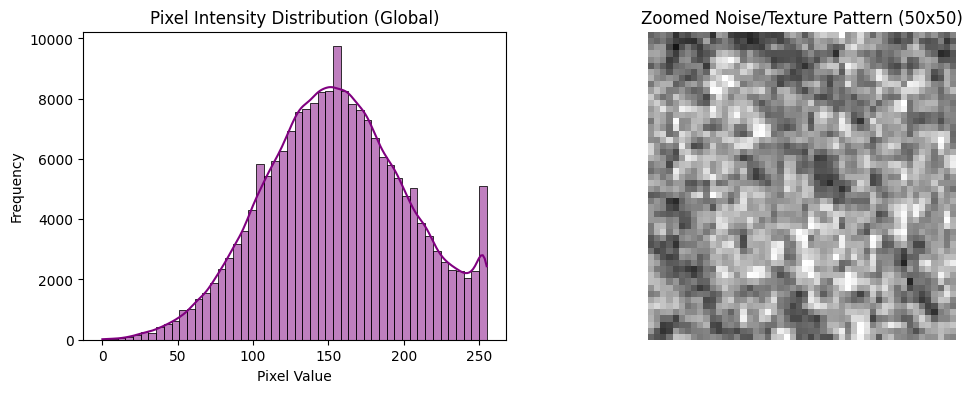

In [5]:
# --- EXECUTE EDA ---
if train_imgs:
    # Process the first image found
    print("## 1. Initial Inspection")
    raw_img, raw_mask = visualize_sample(train_imgs[0], train_masks[0])

    if raw_img is not None:
        print("\n## 2. SAR Noise & Intensity Analysis")
        analyze_sar_noise(raw_img)


In [6]:
# ==========================================
# 3. PREPROCESSING & AUGMENTATION
# ==========================================

def preprocess_sar_data(image, mask, target_size=(256, 256)):
    """
    Applies Resize, Denoising, Normalization, and CLAHE.
    """
    # 1. Resize
    # Use INTER_LINEAR for images, INTER_NEAREST for masks (to keep class integers)
    img_resized = cv2.resize(image, target_size, interpolation=cv2.INTER_LINEAR)
    mask_resized = cv2.resize(mask, target_size, interpolation=cv2.INTER_NEAREST)

    # 2. Denoising (SAR Specific)
    # Median Blur is excellent for salt-and-pepper (speckle) noise
    # Kernel size 3 or 5 is standard.
    if len(img_resized.shape) == 2:
        img_denoised = cv2.medianBlur(img_resized, 3)
    else:
        img_denoised = cv2.medianBlur(img_resized, 3)

    # 3. Enhancement: CLAHE (Contrast Limited Adaptive Histogram Equalization)
    # Very important for SAR to visualize features hidden in dark/bright spots
    if len(img_denoised.shape) == 2: # Grayscale
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        img_enhanced = clahe.apply(img_denoised)
    else:
        # If RGB, apply to L channel of LAB
        lab = cv2.cvtColor(img_denoised, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        cl = clahe.apply(l)
        limg = cv2.merge((cl,a,b))
        img_enhanced = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)

    # 4. Normalization (0 to 1)
    img_normalized = img_enhanced.astype('float32') / 255.0

    return img_normalized, mask_resized




## 3. Preprocessing: Before vs After


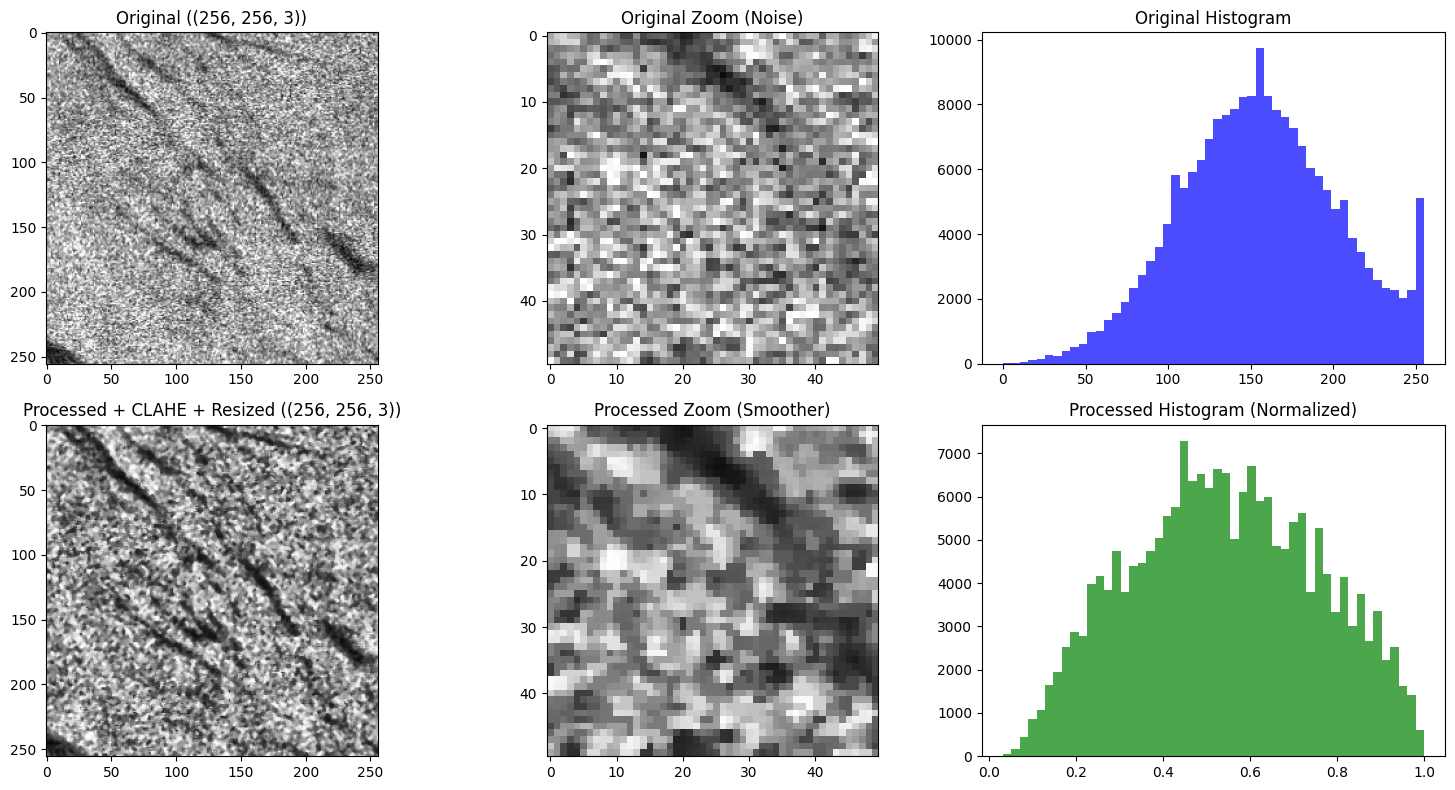


## 4. Augmentation Examples


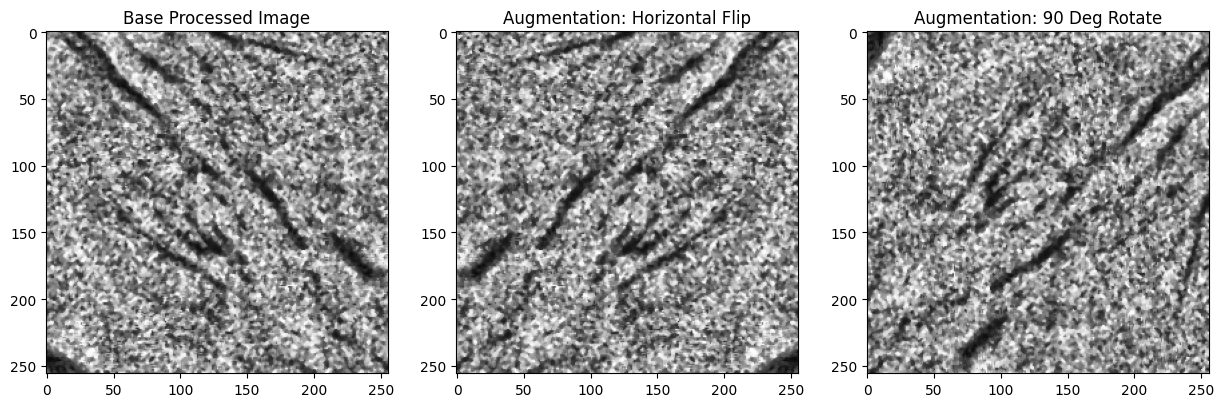

In [7]:
def augment_data(image, mask):
    """
    Simple Augmentations: Flip and Rotation.
    """
    # Horizontal Flip
    img_flip = cv2.flip(image, 1)
    mask_flip = cv2.flip(mask, 1)

    # 90 Degree Rotation
    img_rot = cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)
    mask_rot = cv2.rotate(mask, cv2.ROTATE_90_CLOCKWISE)

    return (img_flip, mask_flip), (img_rot, mask_rot)

# --- EXECUTE PREPROCESSING COMPARISON ---
if train_imgs and raw_img is not None:
    print("\n## 3. Preprocessing: Before vs After")

    # Apply pipeline
    proc_img, proc_mask = preprocess_sar_data(raw_img, raw_mask, TARGET_SIZE)

    fig, ax = plt.subplots(2, 3, figsize=(15, 8))

    # Row 1: Raw Data
    ax[0,0].imshow(raw_img, cmap='gray' if len(raw_img.shape)==2 else None)
    ax[0,0].set_title(f"Original ({raw_img.shape})")

    # Zoom in on Raw noise
    crop_raw = raw_img[50:100, 50:100]
    ax[0,1].imshow(crop_raw, cmap='gray' if len(raw_img.shape)==2 else None)
    ax[0,1].set_title("Original Zoom (Noise)")

    ax[0,2].hist(raw_img.ravel(), bins=50, color='blue', alpha=0.7)
    ax[0,2].set_title("Original Histogram")

    # Row 2: Processed Data
    ax[1,0].imshow(proc_img, cmap='gray' if len(proc_img.shape)==2 else None)
    ax[1,0].set_title(f"Processed + CLAHE + Resized ({proc_img.shape})")

    # Zoom in on Processed noise (Check Denoising)
    crop_proc = proc_img[50:100, 50:100]
    ax[1,1].imshow(crop_proc, cmap='gray' if len(proc_img.shape)==2 else None)
    ax[1,1].set_title("Processed Zoom (Smoother)")

    ax[1,2].hist(proc_img.ravel(), bins=50, color='green', alpha=0.7)
    ax[1,2].set_title("Processed Histogram (Normalized)")

    plt.tight_layout()
    plt.show()

    # --- AUGMENTATION VISUALIZATION ---
    print("\n## 4. Augmentation Examples")
    (flip_img, flip_mask), (rot_img, rot_mask) = augment_data(proc_img, proc_mask)

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    ax[0].imshow(proc_img, cmap='gray')
    ax[0].set_title("Base Processed Image")

    ax[1].imshow(flip_img, cmap='gray')
    ax[1].set_title("Augmentation: Horizontal Flip")

    ax[2].imshow(rot_img, cmap='gray')
    ax[2].set_title("Augmentation: 90 Deg Rotate")

    plt.show()